# 통신사 고객 세그먼트 분석 — K-Means

Cell2Cell 고객 데이터에서 행동 및 계약 특성이 유사한 고객을 5개 군집으로 분류한다.

**저장 산출물**

- `models/kmeans_pipeline.joblib`
- `artifacts/customer_segments.csv`
- `artifacts/cluster_profile_index.csv`
- `artifacts/kmeans_k_evaluation.csv`

> 이 분석은 비지도학습이며 `Churn`을 군집 학습에 사용하지 않는다. `Churn`은 군집 생성 이후 사후 분석에만 활용한다.


## 1. 도메인 기반 Feature 선정

K-Means는 Target Label을 사용하지 않기 때문에 이탈 예측 모델의 Feature Importance를 군집 변수 선정 기준으로 사용하지 않았다. 대신 고객의 서로 다른 비즈니스 특성을 대표하도록 8개 변수를 선정하였다.

| Domain | Feature | 선정 근거 |
|---|---|---|
| 고객 가치 | `MonthlyRevenue` | 고객이 발생시키는 월 매출 |
| 전체 사용량 | `MonthlyMinutes` | 월간 서비스 이용 규모 |
| 초과 사용 | `OverageMinutes` | 기본 제공량을 넘는 헤비 유저 특성 |
| 고객 충성도 | `MonthsInService` | 신규 고객과 장기 고객 구분 |
| 단말기 생애주기 | `CurrentEquipmentDays` | 현재 단말기 사용 기간 |
| 서비스 품질 | `DroppedBlockedCalls` | 끊김 및 차단 통화를 종합적으로 표현 |
| 고객 지원 | `CustomerCareCalls` | 고객센터 접촉 및 지원 수요 |
| 계약 규모 | `ActiveSubs` | 고객의 활성 회선 수 |

선정된 Feature는 고객 가치, 이용량, 충성도, 단말기, 품질, 지원, 계약 규모를 균형 있게 반영한다.


In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# 노트북을 notebooks/ 폴더에서 실행하는 저장소 구조 기준
DATA_PATH = Path("../data/raw/cell2celltrain.csv")
MODEL_PATH = Path("../models/kmeans_pipeline.joblib")
ARTIFACT_DIR = Path("../artifacts")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH}을 찾을 수 없습니다. "
        "cell2celltrain.csv를 data/raw/에 배치하세요."
    )

train = pd.read_csv(DATA_PATH)

print("Data shape:", train.shape)
train.head()


Data shape: (51047, 58)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [2]:
# feature 선정은 report(report_C_cluster.md) 참고

final_cluster_features = [
    "MonthlyRevenue",
    "MonthlyMinutes",
    "OverageMinutes",
    "MonthsInService",
    "CurrentEquipmentDays",
    "DroppedBlockedCalls",
    "CustomerCareCalls",
    "ActiveSubs",
]

missing_features = [
    feature for feature in final_cluster_features
    if feature not in train.columns
]

if missing_features:
    raise KeyError(f"데이터에 없는 Feature: {missing_features}")

cluster_df = train[final_cluster_features].copy()

display(cluster_df.describe().T)
display(cluster_df.isna().sum().to_frame("MissingCount"))


,count,mean,std,min,25%,50%,75%,max
MonthlyRevenue,50891.0,58.834492,44.507336,-6.17,33.61,48.46,71.065,1223.38
MonthlyMinutes,50891.0,525.653416,529.871063,0.00,158.00,366.00,723.000,7359.00
OverageMinutes,50891.0,40.027785,96.588076,0.00,0.00,3.00,41.000,4321.00
MonthsInService,51047.0,18.756264,9.800138,6.00,11.00,16.00,24.000,61.00
CurrentEquipmentDays,51046.0,380.545841,253.801982,-5.00,205.00,329.00,515.000,1812.00
DroppedBlockedCalls,51047.0,10.158003,15.555284,0.00,1.70,5.30,12.300,411.70
CustomerCareCalls,51047.0,1.868999,5.096138,0.00,0.00,0.00,1.700,327.30
ActiveSubs,51047.0,1.354340,0.675477,0.00,1.00,1.00,2.000,53.00


,MissingCount
MonthlyRevenue,156
MonthlyMinutes,156
OverageMinutes,156
MonthsInService,0
CurrentEquipmentDays,1
DroppedBlockedCalls,0
CustomerCareCalls,0
ActiveSubs,0


## 2. 전처리

K-Means는 유클리드 거리를 기준으로 군집을 생성하므로 결측치, 극단값 및 변수별 단위 차이를 처리한다.

- 결측치: 학습 데이터의 중앙값으로 대체
- 극단값: 각 Feature의 하위 1%, 상위 1% 경계로 clipping
- 스케일링: `StandardScaler`로 평균 0, 표준편차 1로 변환

극단 고객을 제거하지 않고 경계값으로 제한하여 VIP 및 헤비 유저의 정보는 유지한다.


In [3]:
imputer = SimpleImputer(strategy="median")

cluster_imputed = pd.DataFrame(
    imputer.fit_transform(cluster_df),
    columns=final_cluster_features,
    index=cluster_df.index,
)

lower_bounds = cluster_imputed.quantile(0.01)
upper_bounds = cluster_imputed.quantile(0.99)

cluster_capped = cluster_imputed.clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1,
)

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_capped)

scaling_check = pd.DataFrame(
    {
        "Mean": cluster_scaled.mean(axis=0),
        "Std": cluster_scaled.std(axis=0),
    },
    index=final_cluster_features,
)

scaling_check


,Mean,Std
MonthlyRevenue,2.338456e-17,1.0
MonthlyMinutes,-8.908405e-17,1.0
OverageMinutes,-1.202635e-16,1.0
MonthsInService,1.425345e-16,1.0
CurrentEquipmentDays,0.000000e+00,1.0
DroppedBlockedCalls,-2.227101e-17,1.0
CustomerCareCalls,-6.235884e-17,1.0
ActiveSubs,-5.567753e-17,1.0


## 3. 최적 군집 수 탐색

군집 수는 다음 기준을 종합하여 결정한다.

1. **Elbow Method:** K 증가에 따른 Inertia 감소 폭
2. **Silhouette Score:** 군집 내부 응집도와 군집 간 분리도
3. **군집 규모:** 지나치게 작거나 큰 군집 발생 여부
4. **해석 가능성:** 고객군별 특징이 명확한지
5. **비즈니스 활용성:** 군집별 전략을 설계할 수 있는지


In [4]:
k_rows = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels,
        sample_size=10000,
        random_state=RANDOM_STATE,
    )

    k_rows.append(
        {
            "K": k,
            "Inertia": model.inertia_,
            "SilhouetteScore": score,
        }
    )

k_evaluation = pd.DataFrame(k_rows)
k_evaluation


C:\Users\playdata2\miniforge3\envs\pystudy_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,K,Inertia,SilhouetteScore
0,2,303024.023048,0.387698
1,3,258614.931004,0.222306
2,4,228776.230936,0.227591
3,5,201186.691501,0.234500
4,6,182696.962205,0.232867
5,7,171255.721320,0.237569
6,8,160812.045521,0.240959


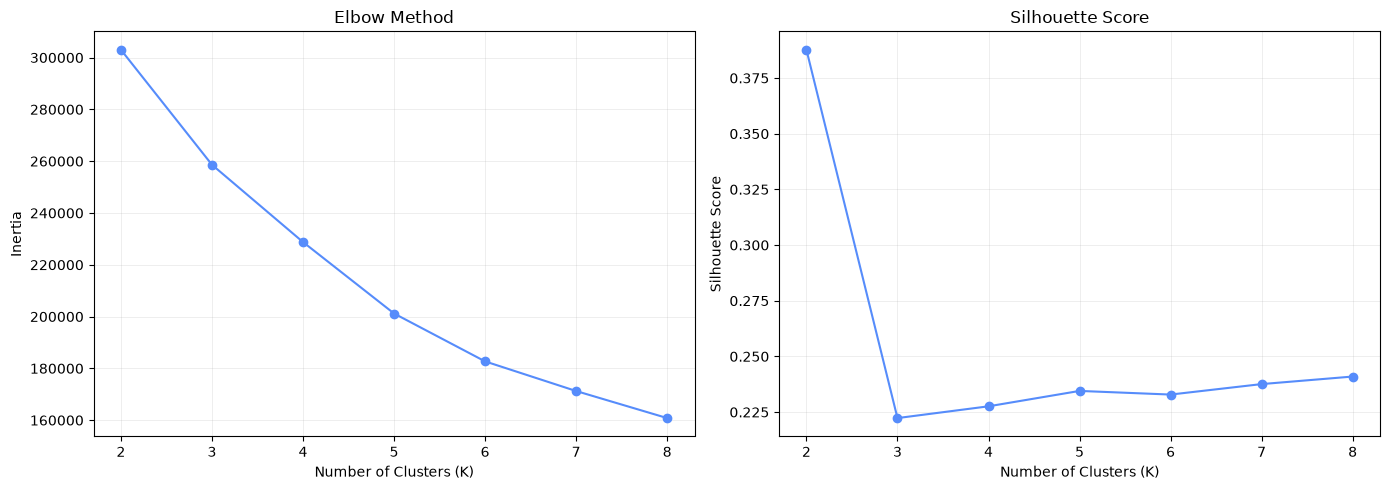

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    k_evaluation["K"],
    k_evaluation["Inertia"],
    marker="o",
)
axes[0].set(
    title="Elbow Method",
    xlabel="Number of Clusters (K)",
    ylabel="Inertia",
)
axes[0].grid(alpha=0.3)

axes[1].plot(
    k_evaluation["K"],
    k_evaluation["SilhouetteScore"],
    marker="o",
)
axes[1].set(
    title="Silhouette Score",
    xlabel="Number of Clusters (K)",
    ylabel="Silhouette Score",
)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### K=5 선정 근거

K=2의 Silhouette Score가 가장 높았지만 두 개의 군집만으로는 고객을 지나치게 넓게 분류하여 마케팅과 고객 관리에 필요한 세부 유형을 제공하기 어렵다.

K=5는 Elbow 곡선의 감소 폭이 완만해지는 구간에 위치하며, 다음 다섯 고객군을 명확하게 해석할 수 있었다.

- Loyal Long-term Customers
- Premium Heavy Users
- Multi-line Customers
- Regular Customers
- High-Maintenance Customers

따라서 가장 높은 Silhouette Score만을 기계적으로 선택하지 않고, Elbow Method, 군집 규모, 해석 가능성 및 비즈니스 활용성을 종합하여 `K=5`를 최종 선택하였다.


In [6]:
FINAL_K = 5

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20,
)

cluster_labels = kmeans.fit_predict(cluster_scaled)

cluster_result = train.copy()
cluster_result["Cluster"] = cluster_labels

cluster_counts = (
    cluster_result["Cluster"]
    .value_counts()
    .sort_index()
    .to_frame("CustomerCount")
)

cluster_counts["Ratio"] = (
    cluster_counts["CustomerCount"]
    / len(cluster_result)
    * 100
)

cluster_counts


,CustomerCount,Ratio
Cluster,,
0,10840,21.235332
1,10861,21.276471
2,3421,6.701667
3,20261,39.690873
4,5664,11.095657


## 4. 군집 프로파일링

군집별 Feature 평균을 전체 고객 평균 대비 지수로 변환한다.

- `100`: 전체 평균과 동일
- `150`: 전체 평균보다 50% 높음
- `70`: 전체 평균보다 30% 낮음


In [7]:
cluster_profile = (
    cluster_result
    .groupby("Cluster")[final_cluster_features]
    .mean()
)

overall_mean = cluster_result[final_cluster_features].mean()

cluster_profile_index = (
    cluster_profile
    .divide(overall_mean, axis=1)
    * 100
)

cluster_profile_index.round(1)


,MonthlyRevenue,MonthlyMinutes,OverageMinutes,MonthsInService,CurrentEquipmentDays,DroppedBlockedCalls,CustomerCareCalls,ActiveSubs
Cluster,,,,,,,,
0,78.3,68.1,47.3,90.1,86.6,62.3,31.3,168.4
1,72.2,48.5,37.6,159.4,189.3,46.9,26.2,89.5
2,291.5,289.7,732.1,103.1,70.9,256.6,164.0,97.1
3,85.0,77.7,49.1,77.7,75.3,65.6,50.2,73.8
4,132.0,224.0,119.2,83.0,60.1,302.4,512.5,84.9


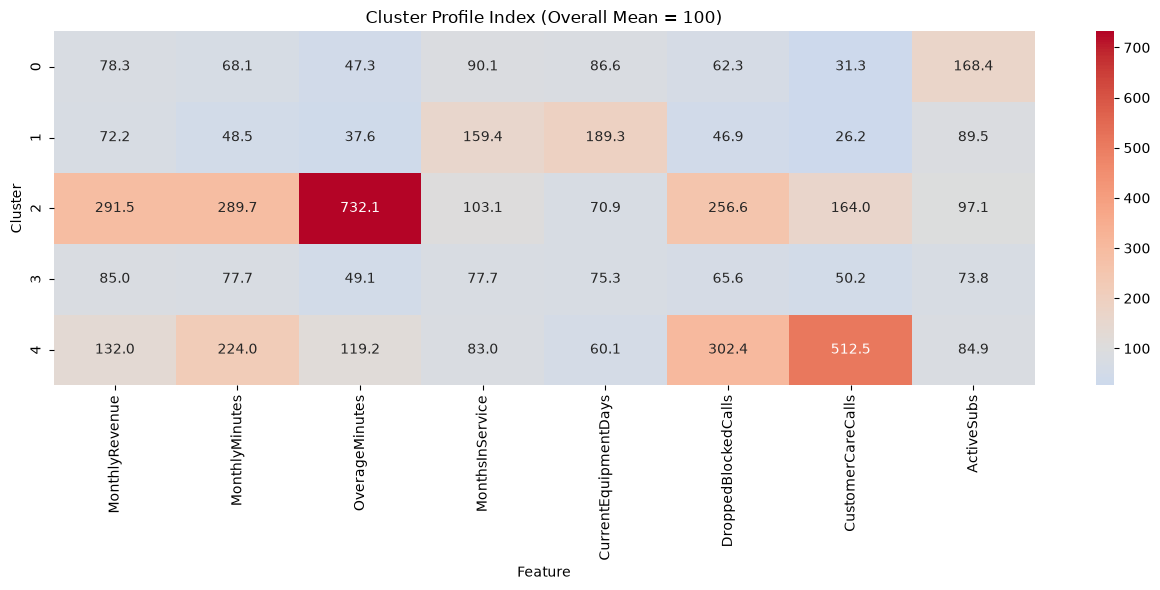

In [8]:
plt.figure(figsize=(13, 6))

sns.heatmap(
    cluster_profile_index,
    annot=True,
    fmt=".1f",
    center=100,
    cmap="coolwarm",
)

plt.title("Cluster Profile Index (Overall Mean = 100)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


## 5. 군집 이름과 비즈니스 의미

군집 번호에는 우열이나 순위 의미가 없다. 군집별 프로파일을 기준으로 다음 이름을 부여한다.

| Segment | 핵심 특징 | 추천 전략 |
|---|---|---|
| Loyal Long-term Customers | 가입 및 단말기 사용 기간이 길고 이용량과 문의가 낮음 | 장기 고객 보상, 단말기 교체 할인, 멤버십 강화 |
| Premium Heavy Users | 매출, 사용량, 초과 사용량이 가장 높은 핵심 고객 | VIP 요금제, 초과 사용 패키지, 프리미엄 지원 |
| Multi-line Customers | 활성 회선 수가 높지만 회선당 이용량과 매출은 낮음 | 가족 결합 할인, 추가 회선 혜택 |
| Regular Customers | 주요 지표가 평균 또는 평균 이하인 일반 고객 | 기본 유지 프로그램, 관심 서비스 기반 업셀링 |
| High-Maintenance Customers | 사용량과 통화 실패, 고객센터 접촉이 매우 높음 | 품질 문제 우선 점검, 전담 상담, 선제 보상 |


In [9]:
# 프로파일을 기준으로 군집 번호와 이름을 자동 연결한다.
remaining = set(cluster_profile_index.index)

premium_heavy = int(
    cluster_profile_index["MonthlyRevenue"].idxmax()
)
remaining.remove(premium_heavy)

high_maintenance = int(
    cluster_profile_index.loc[
        list(remaining), "CustomerCareCalls"
    ].idxmax()
)
remaining.remove(high_maintenance)

multi_line = int(
    cluster_profile_index.loc[
        list(remaining), "ActiveSubs"
    ].idxmax()
)
remaining.remove(multi_line)

loyal_long_term = int(
    cluster_profile_index.loc[
        list(remaining), "MonthsInService"
    ].idxmax()
)
remaining.remove(loyal_long_term)

regular = int(next(iter(remaining)))

cluster_names = {
    loyal_long_term: "Loyal Long-term Customers",
    premium_heavy: "Premium Heavy Users",
    multi_line: "Multi-line Customers",
    regular: "Regular Customers",
    high_maintenance: "High-Maintenance Customers",
}

cluster_result["ClusterName"] = (
    cluster_result["Cluster"].map(cluster_names)
)

cluster_names


{1: 'Loyal Long-term Customers',
 2: 'Premium Heavy Users',
 0: 'Multi-line Customers',
 3: 'Regular Customers',
 4: 'High-Maintenance Customers'}

## 6. 군집별 사후 이탈률

`Churn`은 K-Means 학습에 사용하지 않는다. 군집 생성이 완료된 이후 각 군집의 실제 이탈률을 확인하는 사후 분석에만 사용한다.

따라서 이탈률은 군집을 만든 정답이 아니라, 생성된 고객군의 추가 특성을 설명하는 지표다.


In [10]:
cluster_result["ChurnNumeric"] = (
    cluster_result["Churn"]
    .map({"No": 0, "Yes": 1})
)

cluster_churn = (
    cluster_result
    .groupby(["Cluster", "ClusterName"])
    .agg(
        CustomerCount=("Cluster", "size"),
        ChurnRate=("ChurnNumeric", "mean"),
    )
)

cluster_churn["ChurnRate"] *= 100
cluster_churn.round(2)


,,CustomerCount,ChurnRate
Cluster,ClusterName,,
0,Multi-line Customers,10840,29.41
1,Loyal Long-term Customers,10861,33.19
2,Premium Heavy Users,3421,30.75
3,Regular Customers,20261,27.16
4,High-Maintenance Customers,5664,24.08


## 7. PCA 2차원 시각화

PCA는 8차원 Feature 공간을 2차원으로 축약한 참고 시각화다. PCA 그래프에서 군집이 완벽하게 분리되지 않더라도 원래의 8차원 공간에서 K-Means 군집화가 잘못되었다고 단정할 수 없다.


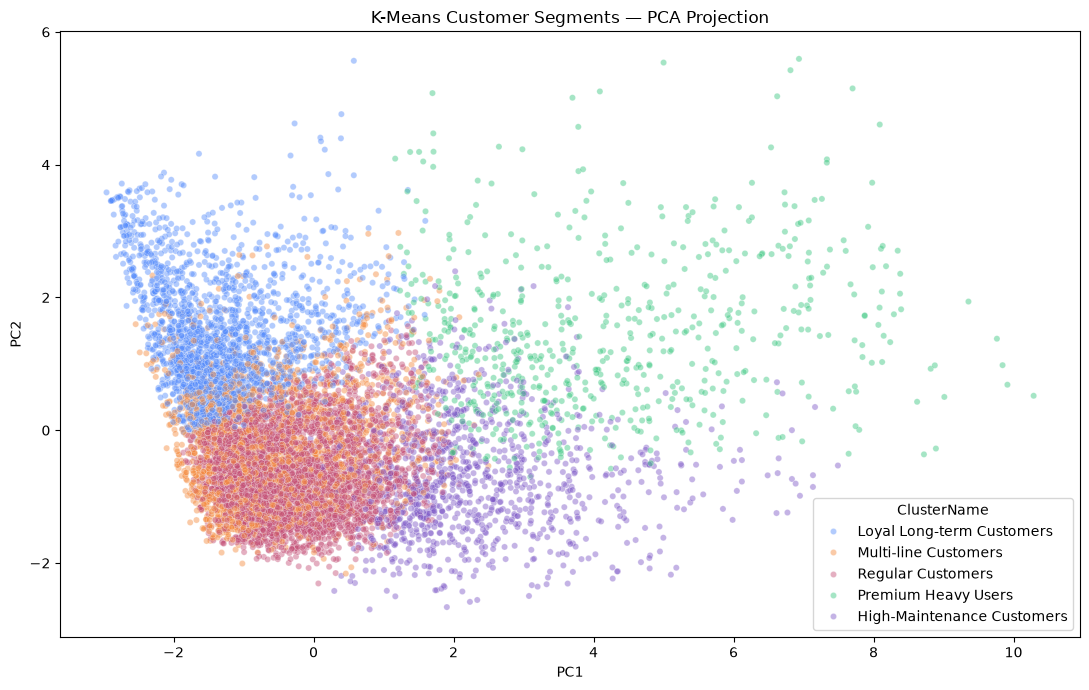

PCA 2D explained variance: 0.5693903410821456


In [11]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

pca_values = pca.fit_transform(cluster_scaled)

pca_df = pd.DataFrame(
    {
        "PC1": pca_values[:, 0],
        "PC2": pca_values[:, 1],
        "Cluster": cluster_labels,
        "ClusterName": cluster_result["ClusterName"],
    }
)

plot_df = pca_df.sample(
    n=min(10000, len(pca_df)),
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="ClusterName",
    alpha=0.45,
    s=20,
)

plt.title("K-Means Customer Segments — PCA Projection")
plt.tight_layout()
plt.show()

print(
    "PCA 2D explained variance:",
    pca.explained_variance_ratio_.sum(),
)


## 8. 모델 및 분석 결과 저장

배포 시 새로운 고객에게 동일한 전처리를 적용해야 하므로 다음 객체를 하나의 모델 번들로 저장한다.

- Feature 목록
- 중앙값 대체기
- 1% 및 99% clipping 경계
- StandardScaler
- 학습된 K-Means
- 군집 번호와 이름의 매핑


In [12]:
model_bundle = {
    "model_type": "KMeans customer segmentation",
    "version": "1.0",
    "feature_names": final_cluster_features,
    "imputer": imputer,
    "lower_bounds": lower_bounds.to_dict(),
    "upper_bounds": upper_bounds.to_dict(),
    "scaler": scaler,
    "kmeans": kmeans,
    "n_clusters": FINAL_K,
    "random_state": RANDOM_STATE,
    "cluster_names": cluster_names,
}

joblib.dump(model_bundle, MODEL_PATH)

cluster_result.to_csv(
    ARTIFACT_DIR / "customer_segments.csv",
    index=False,
    encoding="utf-8-sig",
)

cluster_profile_index.round(1).to_csv(
    ARTIFACT_DIR / "cluster_profile_index.csv",
    encoding="utf-8-sig",
)

k_evaluation.to_csv(
    ARTIFACT_DIR / "kmeans_k_evaluation.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved model:", MODEL_PATH)


Saved model: ..\models\kmeans_pipeline.joblib


### streamlit 구현할 때 필요한 함수
- src에 넣어야 할지 steramlit_app에 넣어야 할지 모르겠어서 일단 노트북에 써 놓겠습니다.
- 아래 사용예시처럼 함수안에 데이터프레임 형식의 값을 대입해주면 됩니다.

In [13]:
def predict_customer_segment(
    new_customers: pd.DataFrame,
    model_path: str | Path = "../models/kmeans_pipeline.joblib",
) -> pd.DataFrame:
    """새로운 고객의 K-Means 군집 번호와 고객군 이름을 반환한다."""

    saved = joblib.load(model_path)
    features = saved["feature_names"]

    missing = [
        feature for feature in features
        if feature not in new_customers.columns
    ]

    if missing:
        raise ValueError(f"필수 컬럼 누락: {missing}")

    transformed = pd.DataFrame(
        saved["imputer"].transform(new_customers[features]),
        columns=features,
        index=new_customers.index,
    )

    transformed = transformed.clip(
        lower=pd.Series(saved["lower_bounds"]),
        upper=pd.Series(saved["upper_bounds"]),
        axis=1,
    )

    transformed_scaled = saved["scaler"].transform(transformed)
    labels = saved["kmeans"].predict(transformed_scaled)

    output = new_customers.copy()
    output["Cluster"] = labels
    output["ClusterName"] = (
        pd.Series(labels, index=output.index)
        .map(saved["cluster_names"])
    )

    return output


# 사용 예시
# predict_customer_segment(train.head(5))
